<a href="https://colab.research.google.com/github/jahnavikrishnakancharla/-Lack-of-Access-to-Quality-Learning-Resources-/blob/main/Experiment4(ml).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Demonstrate a Decision Tree Algorithm for Classification and how to perform paramenter tuning to improve its performance**

In [31]:
 import numpy as np
 import pandas as pd
 import matplotlib.pyplot as pyplot
 from sklearn.model_selection import train_test_split
 from sklearn.tree import DecisionTreeClassifier
 from sklearn.metrics import confusion_matrix,classification_report, accuracy_score
 df=pd.read_csv("/content/drive/MyDrive/heart.csv")

In [30]:
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [19]:
print(df.shape)

(1025, 14)


In [20]:
print(df.tail())

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
1020      2   0     2       1  
1021      1   1     3       0  
1022      1   1     2       0  
1023      2   0     2       1  
1024      1   1     3       0  


In [23]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [24]:
print(df.describe())

               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.000000     0.000000    71.000000  

In [25]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [26]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [27]:
print(df.drop_duplicates())

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     52    1   0       125   212    0        1      168      0      1.0   
1     53    1   0       140   203    1        0      155      1      3.1   
2     70    1   0       145   174    0        1      125      1      2.6   
3     61    1   0       148   203    0        1      161      0      0.0   
4     62    0   0       138   294    1        1      106      0      1.9   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
723   68    0   2       120   211    0        0      115      0      1.5   
733   44    0   2       108   141    0        1      175      0      0.6   
739   52    1   0       128   255    0        1      161      1      0.0   
843   59    1   3       160   273    0        0      125      0      0.0   
878   54    1   0       120   188    0        1      113      0      1.4   

     slope  ca  thal  target  
0        2   2     3       0  
1        0   0     3     

In [28]:
print(df.count())

age         1025
sex         1025
cp          1025
trestbps    1025
chol        1025
fbs         1025
restecg     1025
thalach     1025
exang       1025
oldpeak     1025
slope       1025
ca          1025
thal        1025
target      1025
dtype: int64


In [29]:
print(df.filter)

<bound method NDFrame.filter of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2

In [5]:
x=df[['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal']]
y=df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [7]:
from sklearn.preprocessing import StandardScaler
Scalar=StandardScaler()
x_train=Scalar.fit_transform(x_train)
x_test=Scalar.transform(x_test)

In [32]:
dtc=DecisionTreeClassifier(max_depth=3)
dtc.fit(x_train,y_train)
y_pred=dtc.predict(x_test)

In [10]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)


0.8439024390243902


In [11]:
conffusion_matrix=confusion_matrix(y_test,y_pred)
print(conffusion_matrix)

[[81 17]
 [15 92]]


In [12]:
classification_report=classification_report(y_test,y_pred)
print(classification_report)

              precision    recall  f1-score   support

           0       0.84      0.83      0.84        98
           1       0.84      0.86      0.85       107

    accuracy                           0.84       205
   macro avg       0.84      0.84      0.84       205
weighted avg       0.84      0.84      0.84       205



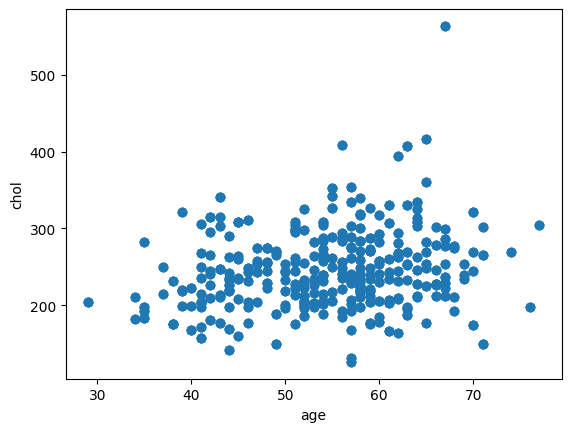

In [14]:
pyplot.scatter(df['age'],df['chol'])
pyplot.xlabel('age')
pyplot.ylabel('chol')
pyplot.show()

# **Part-B (Applying DecisionTree Algorithm to Regressor)**

In [33]:
 import numpy as np
 import pandas as pd
 import matplotlib.pyplot as pyplot
 from sklearn.model_selection import train_test_split
 from sklearn.tree import DecisionTreeRegressor
 from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
 df=pd.read_csv("/content/drive/MyDrive/housing.csv")

In [36]:
x=df[['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income']]
y=df['median_house_value']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)


In [37]:
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)

In [42]:
dtc=DecisionTreeRegressor(max_depth=5)
dtc.fit(x_train,y_train)
y_pred=dtc.predict(x_test)
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))

Mean Absolute Error: 54419.2424421542


In [43]:
print("Mean_Square_Error",mean_squared_error(y_test,y_pred))


Mean_Square_Error 5644574023.038466


In [44]:
print("R2_score",r2_score(y_test,y_pred))

R2_score 0.5671189231300688


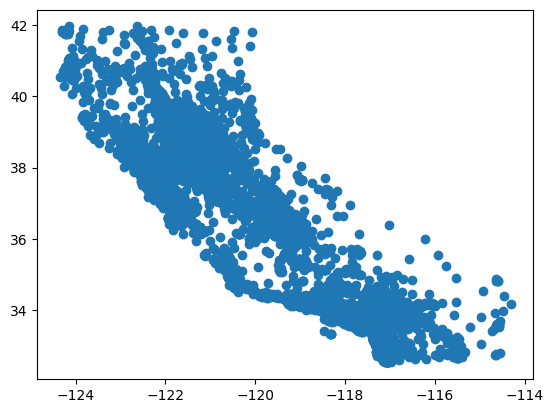

In [48]:
pyplot.scatter(df['longitude'], df['latitude'])
pyplot.show()